In [100]:
import os
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import nltk
import sns
from nltk.corpus import stopwords
import re
from wordcloud import WordCloud

from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense, Dropout, Bidirectional, SpatialDropout1D
from keras.layers import LSTM
import matplotlib.pyplot as plt
from keras.layers import TextVectorization
from keras import optimizers
from keras.utils import to_categorical


from sklearn.metrics import confusion_matrix, cohen_kappa_score, classification_report
from sklearn.metrics import accuracy_score
import warnings

In [50]:
# import tensorflow as tf
# tf.config.run_functions_eagerly(True)

In [51]:
MOSTCOMMONWORDS = 2000 #WORDS = 1000
REVIEWLENGTH = 400 #LENGTH = 100
SAMPLES = 10000 #N = 10000
WORDEMBEDDIM = 12
opt0 = optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
opt1 = optimizers.RMSprop()
EPOCHS = 20
enableStopwords = True

MODELNAME = "brownleeConv1D_LSTM"
VERBOSE = 2
BATCHSIZE = 32
VALIDATIONPERCENT = 0.25

In [52]:
def check_folder(data_path):
    """
    Функция возвращает данные о содержимом папки
    :param data_path: folder path
    """
    folder = Path(data_path)
    
    total_files = 0
    total_folders = 0
    total_size = 0
    extensions = []
    
    for item in folder.rglob('*'):  # рекурсивно пройдем по всем вложенным файлам и папкам
        if item.is_file():
            total_files += 1
            total_size += item.stat().st_size
            ext = item.suffix.lower() if item.suffix else 'без расширения'
            extensions.append(ext)
        elif item.is_dir():
            total_folders += 1
    
    ext_counts = Counter(extensions)
    
    folder_stats = (total_files, total_folders, total_size)
    
    print(f"Статистика папки: {data_path}")
    print(f"Всего файлов: {total_files}")
    print(f"Всего папок (включая вложенные): {total_folders}")
    print(f"Общий размер файлов: {total_size / (1024**2):.2f} МБ")
    print("\nРаспределение по расширениям файлов:")
    for ext, count in ext_counts.most_common():
        print(f"  {ext}: {count}")
    return folder_stats

In [53]:
data_path = os.path.join(str(Path.home()), 'PycharmProjects/ML/src/data', 'drugs')
if not os.path.exists(data_path):
    os.makedirs(data_path)

In [54]:
from kaggle.api.kaggle_api_extended import KaggleApi

folder_stats = check_folder(data_path)
if folder_stats[2] == 0:
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files("jessicali9530/kuc-hackathon-winter-2018", path=data_path, unzip=True)
    print("\nЗагрузка завершена")
    check_folder(data_path)
else:  
    print("\nПапка не пустая")
    check_folder(data_path)

Статистика папки: /Users/aleksandrkoval/PycharmProjects/ML/src/data/drugs
Всего файлов: 2
Всего папок (включая вложенные): 0
Общий размер файлов: 105.50 МБ

Распределение по расширениям файлов:
  .csv: 2

Папка не пустая
Статистика папки: /Users/aleksandrkoval/PycharmProjects/ML/src/data/drugs
Всего файлов: 2
Всего папок (включая вложенные): 0
Общий размер файлов: 105.50 МБ

Распределение по расширениям файлов:
  .csv: 2


In [55]:
folder_stats = check_folder(data_path)

Статистика папки: /Users/aleksandrkoval/PycharmProjects/ML/src/data/drugs
Всего файлов: 2
Всего папок (включая вложенные): 0
Общий размер файлов: 105.50 МБ

Распределение по расширениям файлов:
  .csv: 2


In [56]:
train_df = pd.read_csv(os.path.join(data_path, 'drugsComTrain_raw.csv'))
test_df = pd.read_csv(os.path.join(data_path, 'drugsComTest_raw.csv'))

In [57]:
train_df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [58]:
stemmer = nltk.SnowballStemmer("english")

stopword=set(stopwords.words('english'))

In [59]:
def clean_text(string): 
    string = str(string).lower() # Понизить регистры. Мы будем вызывать CountVectorizer, который по-умолчанию это выполняет, но лишний раз может оказаться не лишним.
    string = re.sub(r"[^a-zA-Z]", " ", string) # Оставляем только латинские буквы. Это сильное условие для английского текста, но не универсальное. Поэтому по развлекаемся точечно.
    string = re.sub(r'\[.*?\]', '', string) # разберёмся с квадратными скобками
    string = re.sub(r'https?://\S+|www\.\S+', '', string) # убрать адресные строки
    string = re.sub(r'<.*?>+', '', string) # убираем случайные HTML-теги
    string = re.sub(r'[^\w\s]', '', string) #убрать всю пунктуацию
    string = re.sub(r'\n', '', string) # удалим все переносы строки
    string = re.sub(r'\w*\d\w*', '', string) # убираем слова с цифрой в середине
    string = [word for word in string.split(' ') if word not in stopword] # очищаем текст от слов исключений
    string= " ".join(string)
    string = [stemmer.stem(word) for word in string.split(' ')] # приводим слова к исходному значению, убирая склонения
    string= " ".join(string)
    string = re.sub('  ', '', string) # уберём все двойные пробелы
    #print(string)
    return string

In [60]:
train_df['review'] = train_df['review'].apply(clean_text)
train_df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,side effecttake combin bystol mg fish oil,9,20-May-12,27
1,95260,Guanfacine,ADHD,son halfway fourth week intunivbecam concern ...,8,27-Apr-10,192
2,92703,Lybrel,Birth Control,use take anoth oral contracept pill cyclhappi...,5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,first time use form birth control glad went p...,8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,suboxon complet turn life around feel healthi...,9,27-Nov-16,37


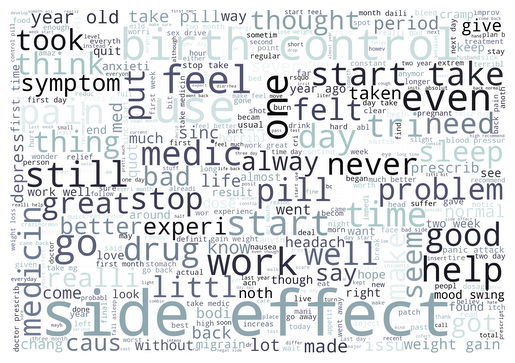

In [105]:
# красивое отображение частоты используемых слов
wordcloud = WordCloud(
    width=2600,
    height=1800,
    random_state=2019,
    background_color='white',
    max_words=400,
    colormap='bone'
)

wordcloud.generate('\n'.join(train_df.review))
plt.imshow(wordcloud, interpolation='lanczos')
plt.axis('off')
plt.show()


In [62]:
train_df.rating.value_counts(normalize=True)

rating
10    0.316119
9     0.170685
1     0.134032
8     0.117113
7     0.058625
5     0.049679
2     0.042970
3     0.040379
6     0.039325
4     0.031073
Name: proportion, dtype: float64

In [63]:
train_df.isnull().sum()

uniqueID         0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64

In [64]:
train_df.duplicated().sum()

np.int64(0)

In [65]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     161297 non-null  int64 
 1   drugName     161297 non-null  object
 2   condition    160398 non-null  object
 3   review       161297 non-null  object
 4   rating       161297 non-null  int64 
 5   date         161297 non-null  object
 6   usefulCount  161297 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 8.6+ MB


In [66]:
print(train_df['review'].dtype)

object


In [67]:
train_df.date.max(), train_df.date.min()

('9-Sep-17', '1-Apr-08')

In [68]:
train_df['rating'].value_counts()

rating
10    50989
9     27531
1     21619
8     18890
7      9456
5      8013
2      6931
3      6513
6      6343
4      5012
Name: count, dtype: int64

In [69]:
train_df.condition.value_counts()

condition
Birth Control                                              28788
Depression                                                  9069
Pain                                                        6145
Anxiety                                                     5904
Acne                                                        5588
                                                           ...  
Dissociative Identity Disorde                                  1
Hydrocephalus                                                  1
Hyperlipoproteinemia Type III, Elevated beta-VLDL   IDL        1
Q Feve                                                         1
Neutropenia                                                    1
Name: count, Length: 884, dtype: int64

In [70]:
train_df.drugName.value_counts()

drugName
Levonorgestrel                       3657
Etonogestrel                         3336
Ethinyl estradiol / norethindrone    2850
Nexplanon                            2156
Ethinyl estradiol / norgestimate     2117
                                     ... 
Omnipaque 350                           1
Vontrol                                 1
Ivabradine                              1
Neo-Poly-Dex                            1
Grifulvin V                             1
Name: count, Length: 3436, dtype: int64

In [71]:
train_df.groupby(['drugName'])['review'].nunique().sort_values(ascending=False).reset_index(name='count').head(20)

,drugName,count
0,Levonorgestrel,3654
1,Etonogestrel,3336
2,Ethinyl estradiol / norethindrone,2849
3,Nexplanon,2156
4,Ethinyl estradiol / norgestimate,2115
5,Ethinyl estradiol / levonorgestrel,1887
6,Phentermine,1543
7,Sertraline,1359
8,Escitalopram,1290
9,Mirena,1241


In [72]:
# выделим пять классов
r = train_df['rating']
labels = \
1* ((0 <= r) & ( r <= 2))  \
+ 2*((3 <= r) & (r <= 4)) \
+ 3*((5 <= r) & (r <= 6)) \
+ 4*((7 <= r) & (r <= 8)) \
+ 5*((9 <= r) & (r <= 10))

labels = labels -1 #скорректируем данные, чтобы классы были от 0 до 4

train_df['label'] = labels
train_df.head(15)

,uniqueID,drugName,condition,review,rating,date,usefulCount,label
0,206461,Valsartan,Left Ventricular Dysfunction,side effecttake combin bystol mg fish oil,9,20-May-12,27,4
1,95260,Guanfacine,ADHD,son halfway fourth week intunivbecam concern ...,8,27-Apr-10,192,3
2,92703,Lybrel,Birth Control,use take anoth oral contracept pill cyclhappi...,5,14-Dec-09,17,2
3,138000,Ortho Evra,Birth Control,first time use form birth control glad went p...,8,3-Nov-15,10,3
4,35696,Buprenorphine / naloxone,Opiate Dependence,suboxon complet turn life around feel healthi...,9,27-Nov-16,37,4
5,155963,Cialis,Benign Prostatic Hyperplasia,nd daymg start work rock hard erect howev expe...,2,28-Nov-15,43,0
6,165907,Levonorgestrel,Emergency Contraception,pullcum bittook plan bhour latertook pregnanc...,1,7-Mar-17,5,0
7,102654,Aripiprazole,Bipolar Disorde,abilifi chang lifehopezoloft clonidin first s...,10,14-Mar-15,32,4
8,74811,Keppra,Epilepsy,noth problem keppera constant shake armampleg...,1,9-Aug-16,11,0
9,48928,Ethinyl estradiol / levonorgestrel,Birth Control,pill mani yeardoctor chang rx chatealeffectre...,8,8-Dec-16,1,3


In [73]:
plt.figure(figsize=(8,8))
sns.distplot(train_df['rating'], kde=False, bins=20)

plt.xlabel('Rating')
plt.ylabel('Dist')
plt.title("Distribution of rating")
plt.show()

AttributeError: module 'sns' has no attribute 'distplot'

<Figure size 800x800 with 0 Axes>

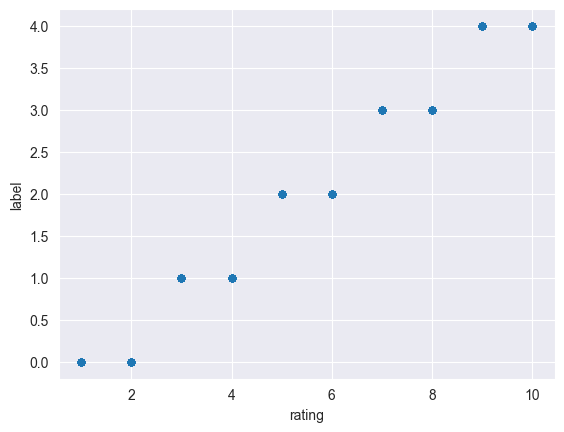

In [74]:
train_df.plot(x = 'rating', y = 'label', kind = 'scatter')
plt.show()

In [75]:
import seaborn as sns
print(sns.__version__)
print(sns.__file__)

0.13.2
/Users/aleksandrkoval/PycharmProjects/ML/virt/lib/python3.12/site-packages/seaborn/__init__.py


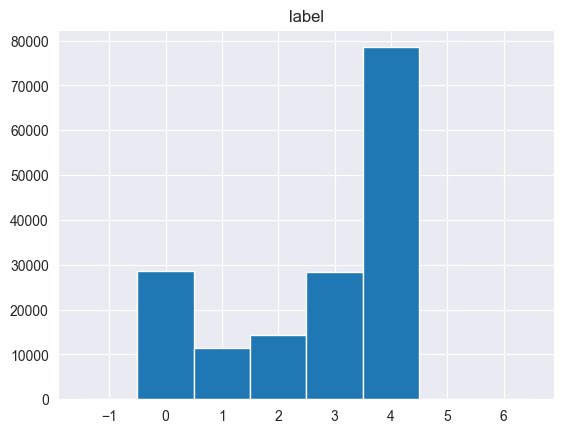

In [76]:
train_df.hist(column = 'label', bins = np.arange(-1, 8), align = 'left');

In [77]:
train_df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount,label
0,206461,Valsartan,Left Ventricular Dysfunction,side effecttake combin bystol mg fish oil,9,20-May-12,27,4
1,95260,Guanfacine,ADHD,son halfway fourth week intunivbecam concern ...,8,27-Apr-10,192,3
2,92703,Lybrel,Birth Control,use take anoth oral contracept pill cyclhappi...,5,14-Dec-09,17,2
3,138000,Ortho Evra,Birth Control,first time use form birth control glad went p...,8,3-Nov-15,10,3
4,35696,Buprenorphine / naloxone,Opiate Dependence,suboxon complet turn life around feel healthi...,9,27-Nov-16,37,4


In [78]:
train_df['review_length'] = train_df['review'].apply(len)
train_df['review_length'].describe()

count    161297.000000
mean        231.088272
std         123.172123
min           0.000000
25%         132.000000
50%         227.000000
75%         339.000000
max        5483.000000
Name: review_length, dtype: float64

In [79]:
train_df['label'].describe(), train_df['label'].unique()

(count    161297.000000
 mean          2.723888
 std           1.542212
 min           0.000000
 25%           2.000000
 50%           3.000000
 75%           4.000000
 max           4.000000
 Name: label, dtype: float64,
 array([4, 3, 2, 0, 1]))

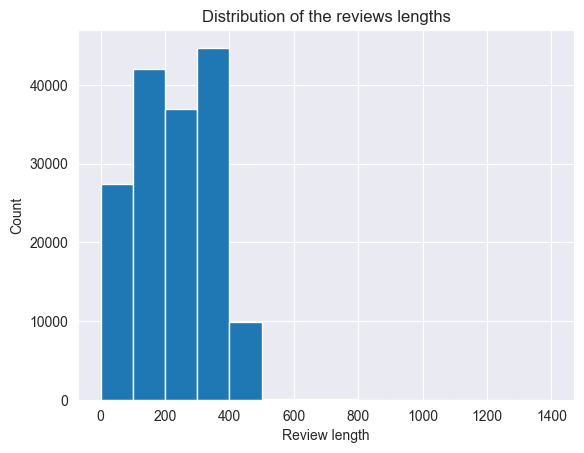

In [80]:
train_df.hist('review_length', bins = np.arange(0, 1500, 100));
plt.title('Distribution of the reviews lengths')
plt.xlabel('Review length')
plt.ylabel('Count')
plt.show()


In [81]:
# Возьмём часть данных для создания тренировочной выборки (x_train)
samples = train_df['review'].iloc[:SAMPLES]

testsamples = train_df['review'].iloc[SAMPLES : 2*SAMPLES] 

In [82]:
# Параметры
# MOSTCOMMONWORDS = 10000
# REVIEWLENGTH = 100

# Создаем слой TextVectorization
vectorize_layer_train = TextVectorization(
    max_tokens=MOSTCOMMONWORDS,
    output_mode='int',                  # Для последовательностей целых чисел (токенов)
    output_sequence_length=REVIEWLENGTH  # Максимальная длина последовательности (паддинг/тримминг)
)
# Обучаем слой на текстах (аналог fit_on_texts)
vectorize_layer_train.adapt(samples)

# Получаем токенизированные и упорядоченные последовательности
x_train = vectorize_layer_train(samples)

# конвертируем в numpy-матрицу
#x_train = x_train.numpy()

In [83]:
vectorize_layer_test = TextVectorization(
    max_tokens=MOSTCOMMONWORDS,
    output_mode='int',                  # Для последовательностей целых чисел (токенов)
    output_sequence_length=REVIEWLENGTH  # Максимальная длина последовательности (паддинг/тримминг)
)
# Обучаем слой на текстах (аналог fit_on_texts)
vectorize_layer_test.adapt(testsamples)

# Получаем токенизированные и упорядоченные последовательности
x_test = vectorize_layer_test(testsamples)

# конвертируем в numpy-матрицу
#x_test = x_train.numpy()

In [84]:
one_hot_labels = to_categorical(labels[:SAMPLES], num_classes = 5)

testlabels = labels[SAMPLES : 2*SAMPLES]
one_hot_testtargets = to_categorical(testlabels, num_classes = 5)

# Проверим размерность данных
x_train.shape, one_hot_labels.shape

(TensorShape([10000, 400]), (10000, 5))

In [85]:
print(one_hot_labels[:5])

[[0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


In [86]:
print(x_train[0])  # первая последовательность токенов
print(len(x_train[0]))  # должно быть равно REVIEWLENGTH

tf.Tensor(
[   7 1288  510    1   28    1  877    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0 

In [87]:
def plot_history(history):
    f, ax = plt.subplots(1, 2, figsize = (16, 7))
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)
    plt.sca(ax[0])
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.sca(ax[1])
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()
    plt.show()
    
def train_model(model, x, y, e = EPOCHS, bs = BATCHSIZE, v = VERBOSE, vs = VALIDATIONPERCENT):
    h = model.fit(x, y, batch_size = bs, epochs = e,  verbose = v, validation_split = vs)
    return h

In [88]:
# model = Sequential()
# model.add(Embedding(MOSTCOMMONWORDS, WORDEMBEDDIM, input_shape=(REVIEWLENGTH,)))
# model.add(Conv1D(filters=WORDEMBEDDIM, kernel_size=3, padding='same', activation='relu'))
# model.add(MaxPooling1D(pool_size=2))
# model.add(LSTM(units = WORDEMBEDDIM, dropout = 0.4, recurrent_dropout = 0.4))
# model.add(Dropout(0.4))
# model.add(Dense(5, activation = 'softmax'))
# model.compile(optimizer = opt1, loss = 'categorical_crossentropy', metrics = ['acc'], run_eagerly = True)
# model.summary()

In [101]:
model = Sequential()
model.add(Embedding(input_dim=MOSTCOMMONWORDS, output_dim=WORDEMBEDDIM, input_shape=(REVIEWLENGTH,), mask_zero=True))
model.add(SpatialDropout1D(0.3))
model.add(Bidirectional(LSTM(units=WORDEMBEDDIM, dropout=0.4, recurrent_dropout=0.4, return_sequences=False)))  # возвращает 2D тензор
model.add(Dropout(0.4))
model.add(Dense(5, activation='softmax'))  # 5 классов

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])

model.summary()

/Users/aleksandrkoval/PycharmProjects/ML/virt/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 400, 12)        │        24,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 400, 12)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 24)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,525 (103.61 KB)

 Trainable params: 26,525 (103.61 KB)

 Non-trainable params: 0 (0.00 B)

In [102]:
# обучение модели
h7 = train_model(model, x_train, one_hot_labels)

Epoch 1/20
235/235 - 53s - 227ms/step - acc: 0.4764 - loss: 1.4405 - val_acc: 0.4808 - val_loss: 1.3875
Epoch 2/20
235/235 - 51s - 216ms/step - acc: 0.4887 - loss: 1.3663 - val_acc: 0.4808 - val_loss: 1.3487
Epoch 3/20
235/235 - 51s - 216ms/step - acc: 0.5033 - loss: 1.2977 - val_acc: 0.5064 - val_loss: 1.2814
Epoch 4/20
235/235 - 51s - 218ms/step - acc: 0.5345 - loss: 1.2335 - val_acc: 0.5136 - val_loss: 1.2653
Epoch 5/20
235/235 - 50s - 214ms/step - acc: 0.5457 - loss: 1.1977 - val_acc: 0.5148 - val_loss: 1.2541
Epoch 6/20
235/235 - 50s - 213ms/step - acc: 0.5601 - loss: 1.1688 - val_acc: 0.5096 - val_loss: 1.2639
Epoch 7/20
235/235 - 50s - 213ms/step - acc: 0.5683 - loss: 1.1486 - val_acc: 0.5168 - val_loss: 1.2547
Epoch 8/20
235/235 - 49s - 210ms/step - acc: 0.5725 - loss: 1.1297 - val_acc: 0.5168 - val_loss: 1.2551
Epoch 9/20
235/235 - 49s - 210ms/step - acc: 0.5719 - loss: 1.1191 - val_acc: 0.5192 - val_loss: 1.2560
Epoch 10/20
235/235 - 49s - 210ms/step - acc: 0.5832 - loss: 1.1

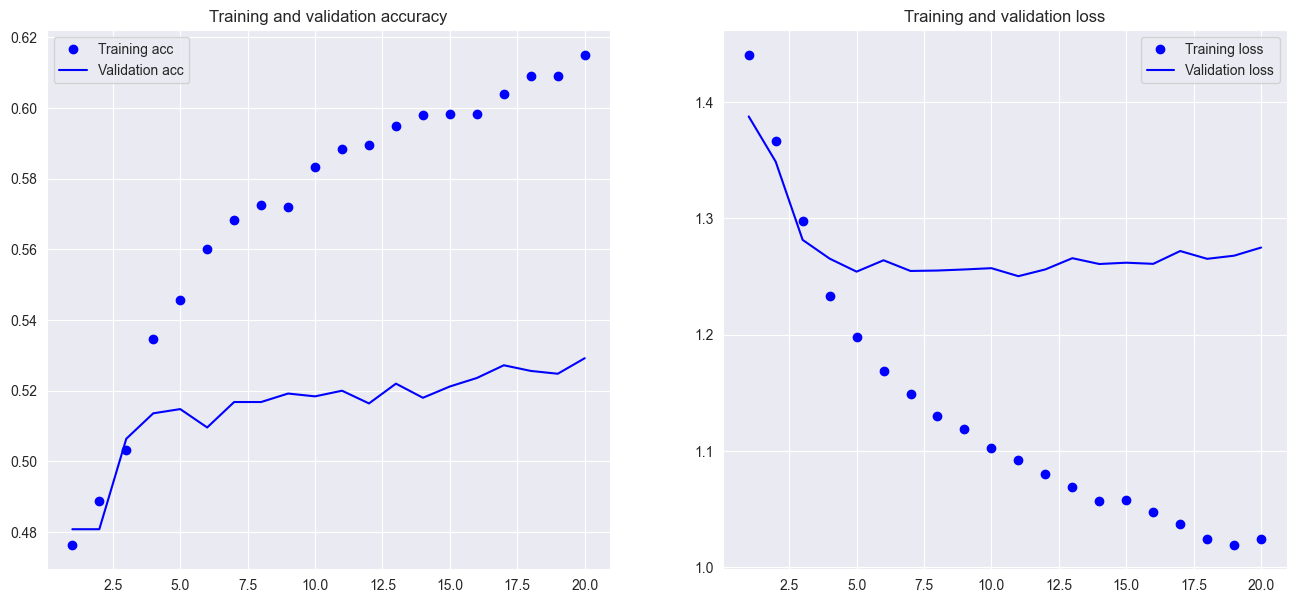

In [103]:
# посмотрим на результат
plot_history(h7)

In [106]:
def display_results(model, test_data, test_targets):
    # Получить правильные и предсказанные данные
    y_true = test_targets
    predict = model.predict(test_data)
    y_pred = np.argmax(predict, axis = 1)
 

    # Вывод данных

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
    
        cm = confusion_matrix(y_true, y_pred)
        print('Confusion matrix:')
        print(cm)
        print('')

        a = accuracy_score(y_true, y_pred)
        print('Accuracy: {:.4f}'.format(a))
        print('')

        cr = classification_report(y_true, y_pred)
        print('Classification report:')
        print(cr)
        
        print('')
        k = cohen_kappa_score(y_true, y_pred, weights = 'quadratic')
        print("Quadratic weighted Cohen's kappa score = {:.4f}".format(k))

In [107]:
y_true = testlabels

In [108]:
predicts = model.predict(x_test)
print(predicts )
print('')

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step
[[0.09719305 0.10630922 0.16517465 0.34666833 0.2846547 ]
 [0.47416028 0.16704805 0.15690726 0.12312592 0.07875845]
 [0.05966447 0.02984084 0.04735465 0.12120654 0.74193347]
 ...
 [0.07031891 0.06310602 0.11757062 0.32337993 0.4256246 ]
 [0.00794748 0.00525889 0.01608692 0.11182597 0.85888076]
 [0.08627006 0.08454078 0.13186418 0.22962436 0.4677007 ]]



In [109]:
y_pred = np.argmax(predicts, axis = 1)
print(y_pred)
print('')

## проверка предсказания
print(np.unique(y_pred))

[3 0 4 ... 4 4 4]

[0 1 2 3 4]


In [110]:
display_results(model, x_test, testlabels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step
Confusion matrix:
[[ 474    7    8  130 1176]
 [ 198    2    4   53  440]
 [ 225   11    7   74  560]
 [ 439    4   27  157 1072]
 [1338   12   59  359 3164]]

Accuracy: 0.3804

Classification report:
              precision    recall  f1-score   support

           0       0.18      0.26      0.21      1795
           1       0.06      0.00      0.01       697
           2       0.07      0.01      0.01       877
           3       0.20      0.09      0.13      1699
           4       0.49      0.64      0.56      4932

    accuracy                           0.38     10000
   macro avg       0.20      0.20      0.18     10000
weighted avg       0.32      0.38      0.34     10000


Quadratic weighted Cohen's kappa score = -0.0054
